In [7]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [8]:
import os


In [9]:
os.listdir()


['.config',
 'task-4 dataset archive (2).zip',
 'archive (2).zip',
 'archive.zip',
 'sample_data']

In [10]:
!unzip "task-4 dataset archive (2).zip"


Archive:  task-4 dataset archive (2).zip
  inflating: clean_dataset.csv       
  inflating: crx.csv                 


In [11]:
import os
os.listdir()


['.config',
 'crx.csv',
 'task-4 dataset archive (2).zip',
 'archive (2).zip',
 'archive.zip',
 'clean_dataset.csv',
 'sample_data']

In [13]:
import pandas as pd

df = pd.read_csv("clean_dataset.csv")
df.head()


,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


In [14]:
print(df.shape)
print(df.columns)
df.info()


(690, 16)
Index(['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'Industry',
       'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore',
       'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'Approved'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    int64  
 1   Age             690 non-null    float64
 2   Debt            690 non-null    float64
 3   Married         690 non-null    int64  
 4   BankCustomer    690 non-null    int64  
 5   Industry        690 non-null    object 
 6   Ethnicity       690 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    int64  
 9   Employed        690 non-null    int64  
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    int64  
 12  Citizen

Scatterplot Matrix

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



Generating Scatterplot Matrix...


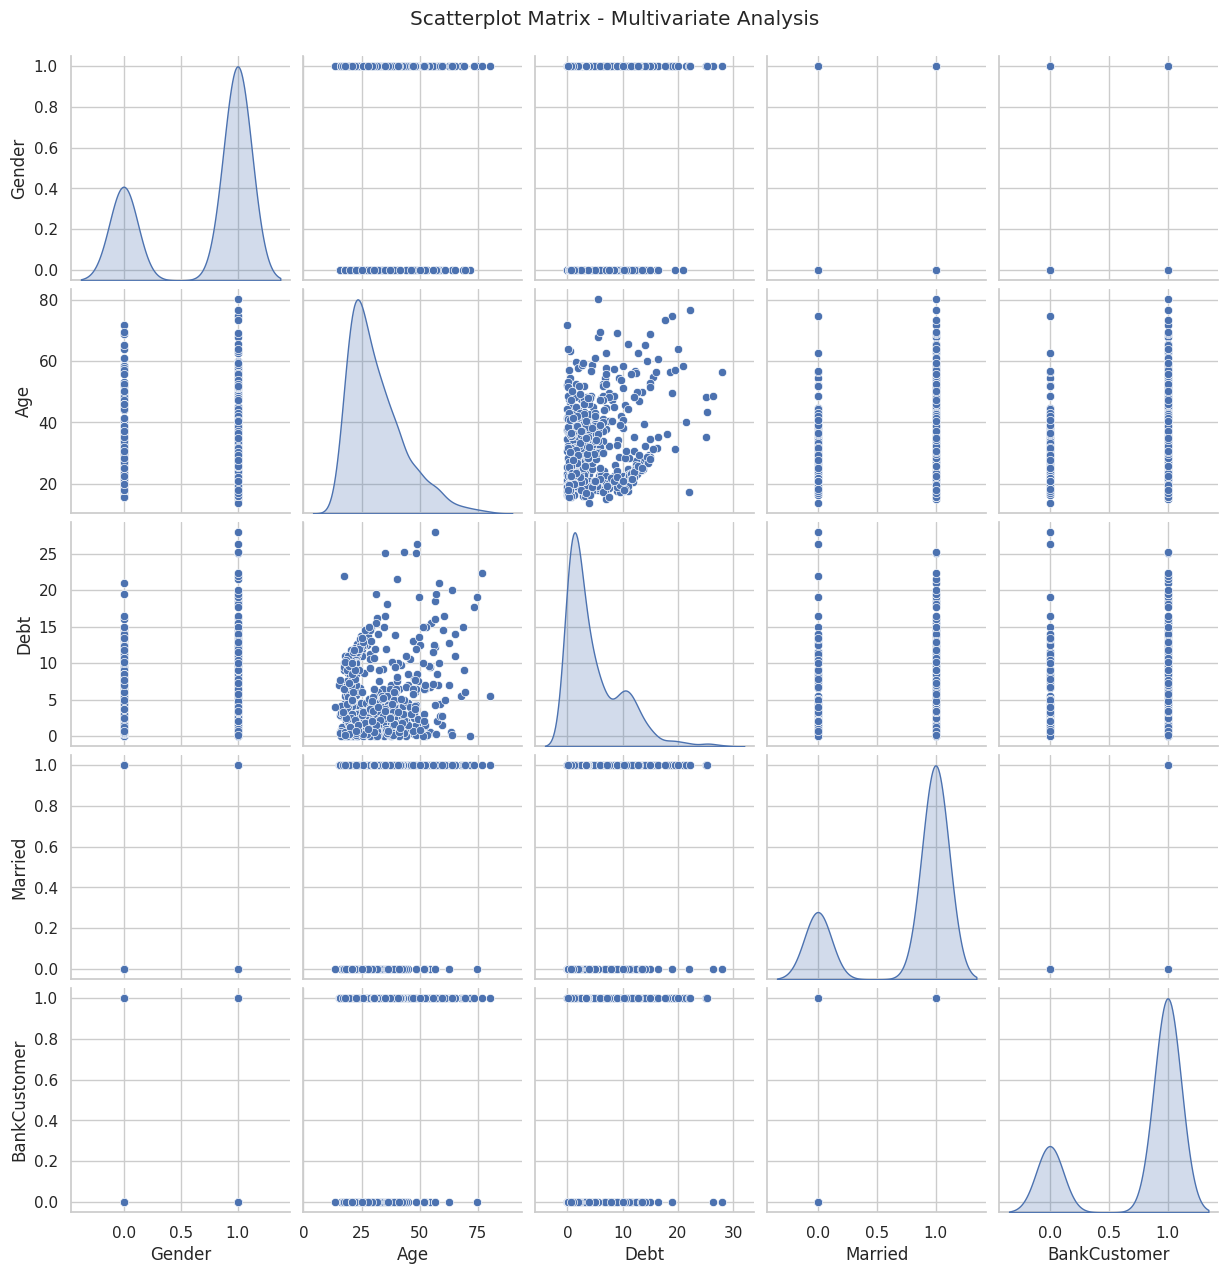

In [33]:
print("\nGenerating Scatterplot Matrix...")

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
selected_num_cols = numerical_cols[:5]  # select first 5 numeric columns

sns.pairplot(df[selected_num_cols], diag_kind='kde')
plt.suptitle("Scatterplot Matrix - Multivariate Analysis", y=1.02)
plt.show()

Parallel Coordinates Plot

/tmp/ipython-input-810225495.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      1
1      1
2      1
3      1
4      1
      ..
685    0
686    1
687    0
688    1
689    1
Name: BankCustomer, Length: 690, dtype: object' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.iloc[:, -1] = data.iloc[:, -1].astype(str)


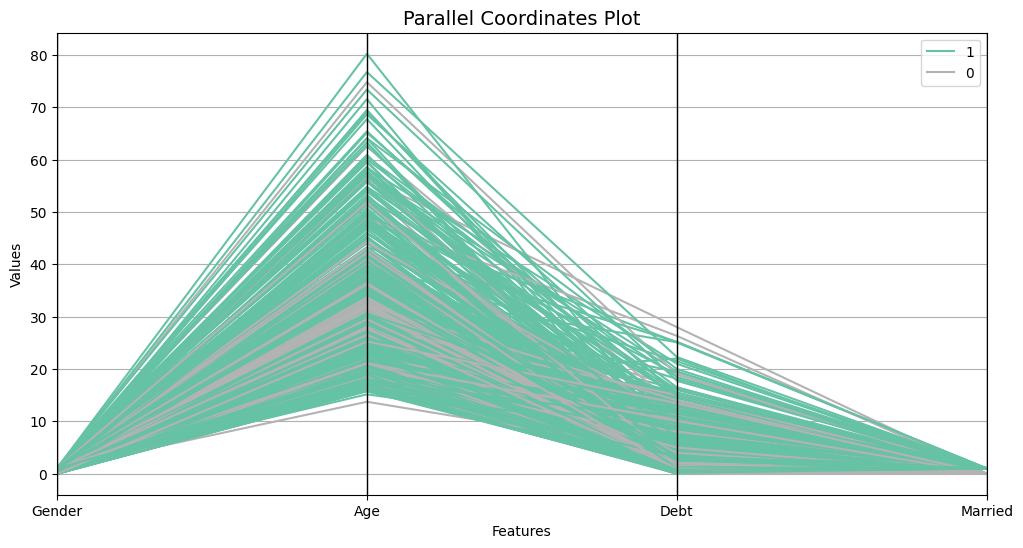

In [16]:
from pandas.plotting import parallel_coordinates

# Select few columns (adjust if needed)
data = df.iloc[:, :5].copy()

data.iloc[:, -1] = data.iloc[:, -1].astype(str)

plt.figure(figsize=(12,6))

parallel_coordinates(
    data,
    data.columns[-1],
    colormap=plt.cm.Set2
)

plt.title("Parallel Coordinates Plot", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Values")
plt.grid(True)
plt.show()


Line Graph

Generating Line Graph...


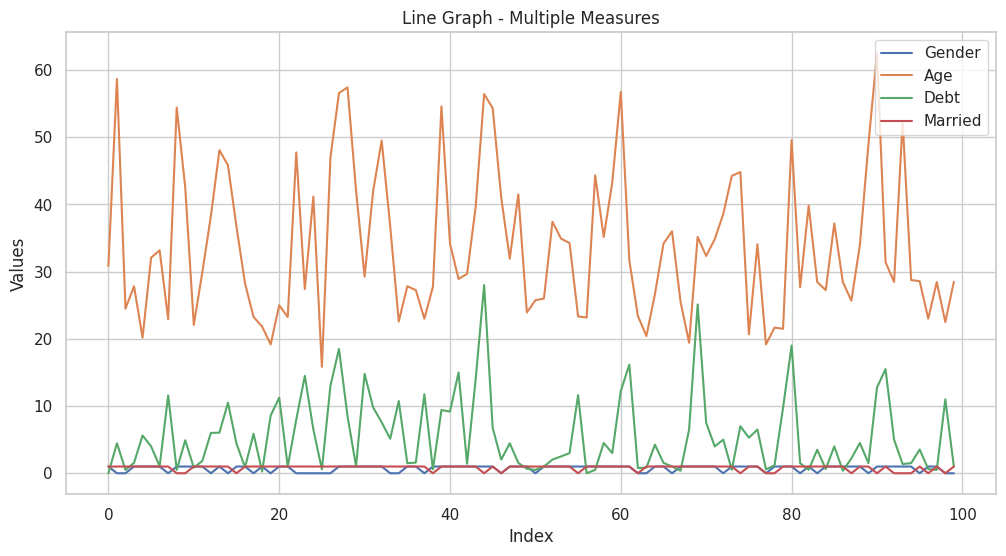

In [35]:
print("Generating Line Graph...")

plt.figure(figsize=(12,6))

for col in selected_num_cols[:4]:
    plt.plot(df[col].head(100), label=col)

plt.legend()
plt.title("Line Graph - Multiple Measures")
plt.xlabel("Index")
plt.ylabel("Values")
plt.show()

Stacked Bar Chart

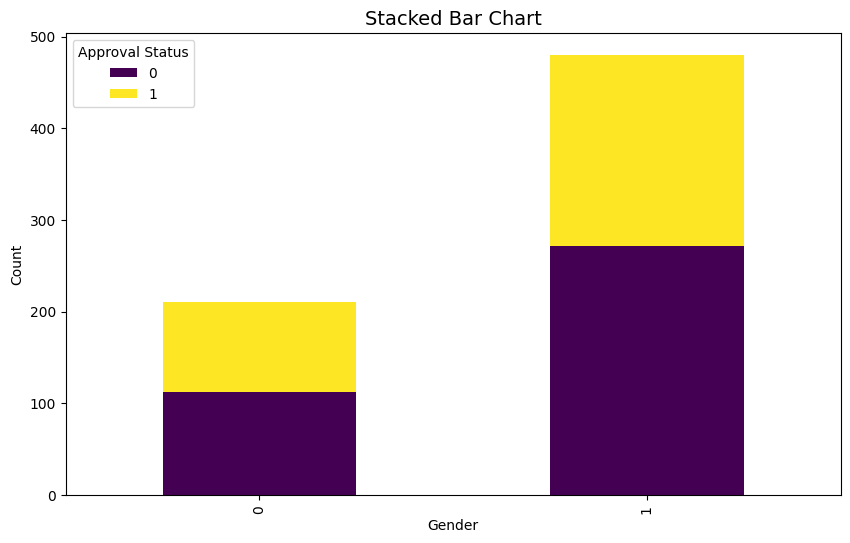

In [18]:
ct = pd.crosstab(df.iloc[:,0], df.iloc[:,-1])

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='viridis'
)

plt.title("Stacked Bar Chart", fontsize=14)
plt.xlabel(df.columns[0])
plt.ylabel("Count")
plt.legend(title="Approval Status")
plt.show()


Interactive Parallel Coordinates Plot

In [19]:
!pip install plotly


In [20]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


In [25]:
# Convert approval column to numeric if needed
df[df.columns[-1]] = df[df.columns[-1]].astype('category').cat.codes

fig = px.parallel_coordinates(
    df,
    dimensions=df.select_dtypes(include=['int64','float64']).columns[:5],
    color=df.columns[-1],
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Interactive Parallel Coordinates Plot"
)

fig.update_layout(font=dict(size=14))
fig.show()
